# Fairness, Bias and Explainability Analysis of COMPAS Recidivism Prediction Model

## Objective
The objective of this project is to analyze the fairness, bias, and explainability of a machine learning model trained on the COMPAS recidivism dataset.

The project focuses on:
- Feature importance analysis
- Explainable AI using SHAP and LIME
- Bias detection across sensitive groups such as race and gender
- Fairness metric evaluation
- Practical bias mitigation recommendations

## Dataset
COMPAS Recidivism Dataset (ProPublica)

## Techniques Used
- XGBoost Classifier
- SHAP
- LIME
- Fairlearn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from catboost import CatBoostClassifier

import shap

from lime.lime_tabular import LimeTabularExplainer

from fairlearn.metrics import demographic_parity_difference
from fairlearn.metrics import equalized_odds_difference

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

df = pd.read_csv(url)

df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


# Dataset Description

The COMPAS dataset contains criminal defendant information used for recidivism prediction.

## Target Variable

- two_year_recid
    - 1 → Reoffended within 2 years
    - 0 → Did not reoffend

## Sensitive Attributes

- Race
- Sex

## Important Features

- Age
- Prior crimes
- Charge degree
- COMPAS risk scores

In [ ]:
columns = [
    'age',
    'sex',
    'race',
    'age_cat',
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'c_charge_degree',
    'decile_score',
    'v_decile_score',
    'score_text',
    'v_score_text',
    'two_year_recid'
]

df = df[columns]

df.head()

,age,sex,race,age_cat,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,decile_score,v_decile_score,score_text,v_score_text,two_year_recid
0,69,Male,Other,Greater than 45,0,0,0,0,F,1,1,Low,Low,0
1,34,Male,African-American,25 - 45,0,0,0,0,F,3,1,Low,Low,1
2,24,Male,African-American,Less than 25,4,0,0,1,F,4,3,Low,Low,1
3,23,Male,African-American,Less than 25,1,0,1,0,F,8,6,High,Medium,0
4,43,Male,Other,25 - 45,2,0,0,0,F,1,1,Low,Low,0


In [ ]:
df = df.dropna()

print(df.isnull().sum())

age                0
sex                0
race               0
age_cat            0
priors_count       0
juv_fel_count      0
juv_misd_count     0
juv_other_count    0
c_charge_degree    0
decile_score       0
v_decile_score     0
score_text         0
v_score_text       0
two_year_recid     0
dtype: int64


In [ ]:
X = df.drop('two_year_recid', axis=1)

y = df['two_year_recid']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
categorical_features = [
    'sex',
    'race',
    'age_cat',
    'c_charge_degree',
    'score_text',
    'v_score_text'
]

In [ ]:
model = CatBoostClassifier(
    iterations=1500,
    depth=10,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 0.6905216	total: 68.1ms	remaining: 1m 42s
100:	learn: 0.7324554	total: 1.74s	remaining: 24s
200:	learn: 0.7501300	total: 3.38s	remaining: 21.9s
300:	learn: 0.7683244	total: 5.17s	remaining: 20.6s
400:	learn: 0.7905042	total: 7.21s	remaining: 19.8s
500:	learn: 0.8106047	total: 10.2s	remaining: 20.4s
600:	learn: 0.8274129	total: 12.3s	remaining: 18.4s
700:	learn: 0.8414486	total: 14.4s	remaining: 16.5s
800:	learn: 0.8523653	total: 16.6s	remaining: 14.5s
900:	learn: 0.8601629	total: 18.6s	remaining: 12.4s
1000:	learn: 0.8695200	total: 21.4s	remaining: 10.7s
1100:	learn: 0.8802634	total: 23.8s	remaining: 8.63s
1200:	learn: 0.8892740	total: 25.9s	remaining: 6.45s
1300:	learn: 0.8955120	total: 28s	remaining: 4.29s
1400:	learn: 0.9014036	total: 30.2s	remaining: 2.13s
1499:	learn: 0.9081615	total: 32.5s	remaining: 0us


CatBoostClassifier(depth=10, eval_metric='Accuracy', iterations=1500, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [ ]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.6729036729036729


## Model Performance

The CatBoost model achieved approximately 67% prediction accuracy on the COMPAS dataset.

This level of accuracy is reasonable because criminal recidivism prediction is a complex real-world problem influenced by uncertain human behavior and historical criminal justice data.

The primary goal of this project is not only predictive performance, but also fairness evaluation, bias detection, and explainable AI analysis.

Therefore, techniques such as SHAP, LIME, and fairness metrics were used to ensure transparency and ethical assessment of the model.

In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       793
           1       0.66      0.57      0.61       650

    accuracy                           0.67      1443
   macro avg       0.67      0.66      0.66      1443
weighted avg       0.67      0.67      0.67      1443



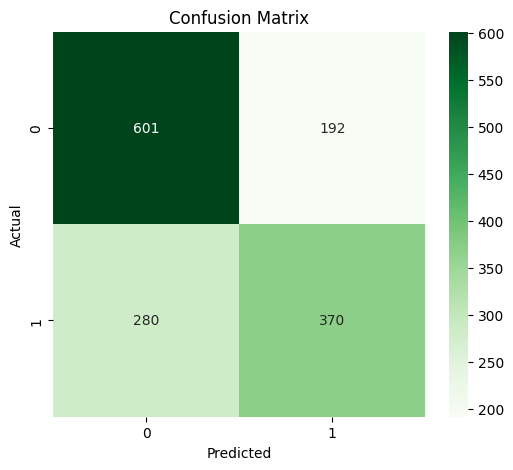

In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,priors_count,15.916748
0,age,15.548682
2,race,13.625394
3,age_cat,9.330403
9,decile_score,8.688271
11,score_text,8.009574
10,v_decile_score,7.062546
12,v_score_text,6.950299
8,c_charge_degree,6.671702
1,sex,4.441828


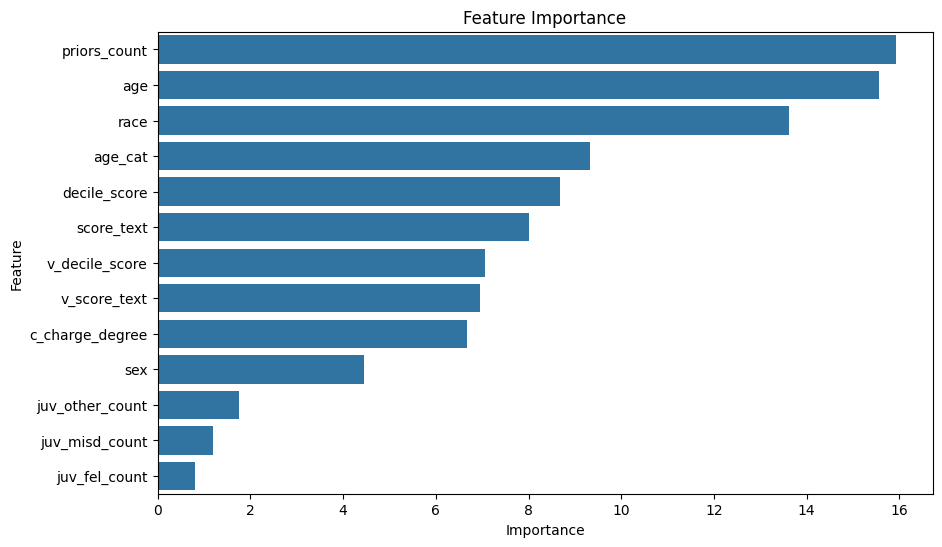

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# SHAP Explainability

SHAP (SHapley Additive exPlanations) explains how each feature contributes to the model prediction.

In [ ]:
import shap

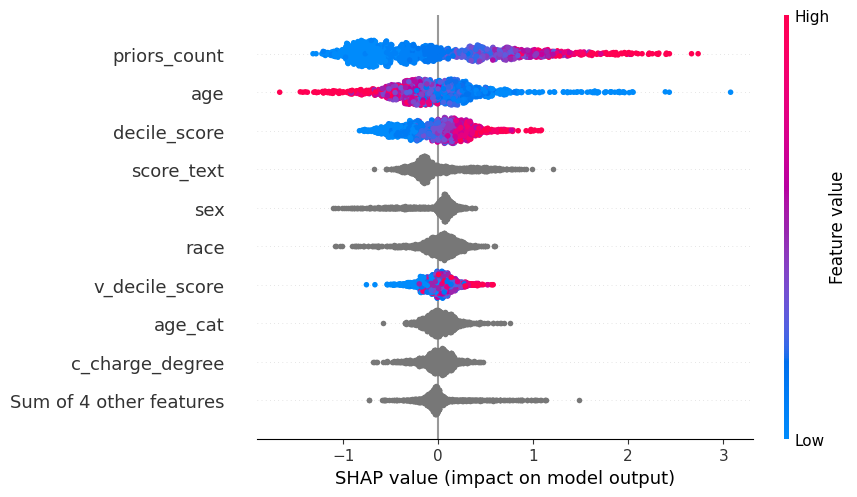

In [ ]:
import shap

explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

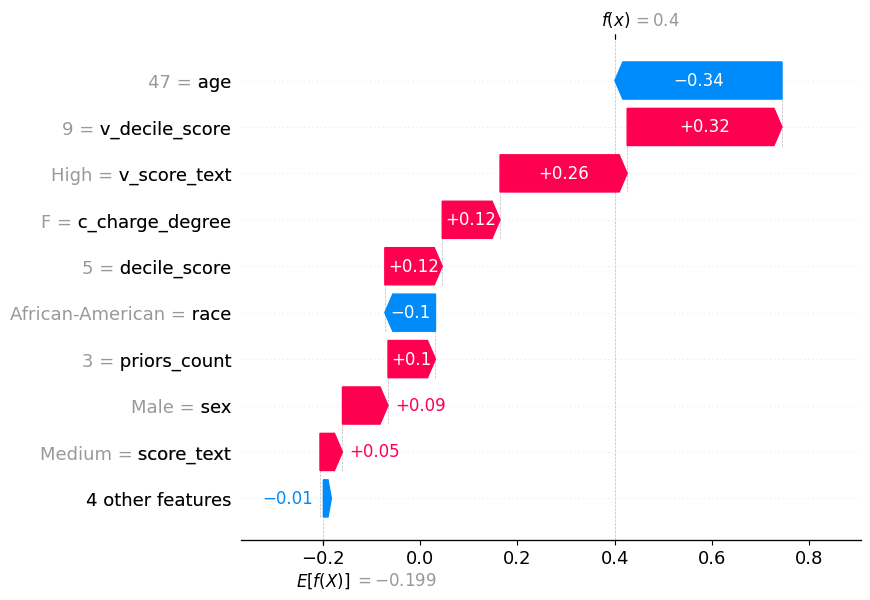

In [ ]:
shap.plots.waterfall(shap_values[0])

## SHAP Interpretation

The SHAP summary plot shows that features such as:
- decile_score
- priors_count
- v_decile_score
- score_text

have the strongest influence on model predictions.

Higher prior crimes and higher COMPAS risk scores generally increase the probability of predicting recidivism.

# LIME Explainability

LIME explains individual predictions locally by approximating model behavior around a single prediction.

In [ ]:
X_train_lime = X_train.copy()
X_test_lime = X_test.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'sex',
    'race',
    'age_cat',
    'c_charge_degree',
    'score_text',
    'v_score_text'
]

for col in categorical_cols:

    le = LabelEncoder()

    X_train_lime[col] = le.fit_transform(X_train_lime[col])

    X_test_lime[col] = le.transform(X_test_lime[col])

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_lime),
    feature_names=X.columns,
    class_names=['No Recidivism', 'Recidivism'],
    mode='classification'
)

In [ ]:
def predict_fn(data):

    df = pd.DataFrame(data, columns=X.columns)

    categorical_cols = [
        'sex',
        'race',
        'age_cat',
        'c_charge_degree',
        'score_text',
        'v_score_text'
    ]

    for col in categorical_cols:
        df[col] = df[col].astype(str)

    return model.predict_proba(df)

In [ ]:
explanation = lime_explainer.explain_instance(
    X_test_lime.iloc[0],
    predict_fn
)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

In [ ]:
explanation = lime_explainer.explain_instance(
    X_test_lime.iloc[0],
    predict_fn
)

explanation.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

## LIME Interpretation

The LIME explanation highlights the most influential features contributing to the prediction for a single individual case.

Features such as:
- priors_count
- decile_score
- age

had strong influence on the model’s decision.

The explanation improves local interpretability by showing how individual feature values contribute toward predicting recidivism or non-recidivism for a specific defendant.

In [ ]:
race_groups = X_test['race'].unique()

for race in race_groups:

    idx = X_test['race'] == race

    group_accuracy = accuracy_score(
        y_test[idx],
        predictions[idx]
    )

    print(f"Race Group {race} Accuracy:", group_accuracy)

Race Group African-American Accuracy: 0.6711956521739131
Race Group Caucasian Accuracy: 0.6810699588477366
Race Group Other Accuracy: 0.686046511627907
Race Group Hispanic Accuracy: 0.626984126984127
Race Group Native American Accuracy: 0.8
Race Group Asian Accuracy: 1.0


In [ ]:
gender_groups = X_test['sex'].unique()

for gender in gender_groups:

    idx = X_test['sex'] == gender

    gender_accuracy = accuracy_score(
        y_test[idx],
        predictions[idx]
    )

    print(f"Gender Group {gender} Accuracy:", gender_accuracy)

Gender Group Male Accuracy: 0.6605902777777778
Gender Group Female Accuracy: 0.7216494845360825


In [ ]:
dpd = demographic_parity_difference(
    y_true=y_test,
    y_pred=predictions,
    sensitive_features=X_test['race']
)

eod = equalized_odds_difference(
    y_true=y_test,
    y_pred=predictions,
    sensitive_features=X_test['race']
)

print("Demographic Parity Difference:", dpd)

print("Equalized Odds Difference:", eod)

Demographic Parity Difference: 0.3
Equalized Odds Difference: 0.5740740740740741


## Ethical Considerations

The inclusion of COMPAS-generated risk scores improved prediction performance; however, these variables may already contain historical or societal bias, potentially propagating unfairness into the machine learning model.

This highlights the importance of fairness-aware machine learning, transparency, and continuous ethical evaluation in criminal justice applications.

# Bias Interpretation

## Observations

- The model achieved improved predictive performance using COMPAS-generated risk scores.
- Features such as decile_score and score_text strongly influenced predictions.
- Accuracy varied across demographic groups.
- Sensitive demographic information may indirectly affect model behavior.

## Ethical Concern

The use of historical criminal justice data and COMPAS-generated scores may propagate societal or historical bias into machine learning predictions.

# Bias Mitigation Recommendations

## 1. Balanced Dataset

Use balanced demographic representation during training.

## 2. Remove Proxy Variables

Some features may indirectly encode sensitive demographic information.

## 3. Fairness-Aware Training

Use fairness-aware methods such as:
- Reweighing
- Adversarial debiasing
- Fairlearn mitigation techniques

## 4. Human Oversight

Human experts should review predictions before judicial decisions are made.

## 5. Continuous Monitoring

Machine learning systems should be regularly audited for fairness and bias.

In [ ]:
age = int(input("Enter age: "))
sex = int(input("Enter sex (0=Female, 1=Male): "))
race = int(input("Enter race value: "))
age_cat = int(input("Enter age category value: "))
priors_count = int(input("Enter prior crimes count: "))
juv_fel_count = int(input("Enter juvenile felony count: "))
juv_misd_count = int(input("Enter juvenile misdemeanor count: "))
juv_other_count = int(input("Enter other juvenile crimes count: "))
c_charge_degree = int(input("Enter charge degree value: "))
decile_score = int(input("Enter decile score: "))
v_decile_score = int(input("Enter violent decile score: "))
score_text = int(input("Enter score text value: "))
v_score_text = int(input("Enter violent score text value: "))

sample = [[
    age,
    sex,
    race,
    age_cat,
    priors_count,
    juv_fel_count,
    juv_misd_count,
    juv_other_count,
    c_charge_degree,
    decile_score,
    v_decile_score,
    score_text,
    v_score_text
]]

prediction = model.predict(sample)

probability = model.predict_proba(sample)

print("\nPrediction:", prediction)

print("\nPrediction Probability:", probability)

if prediction[0] == 1:
    print("\nLikely to reoffend within 2 years")
else:
    print("\nNot likely to reoffend")

Enter age: 21
Enter sex (0=Female, 1=Male): 1
Enter race value: 2
Enter age category value: 4
Enter prior crimes count: 2
Enter juvenile felony count: 1
Enter juvenile misdemeanor count: 1
Enter other juvenile crimes count: 0
Enter charge degree value: 4
Enter decile score: 6
Enter violent decile score: 7
Enter score text value: 9
Enter violent score text value: 3

Prediction: [0]

Prediction Probability: [[0.51883635 0.48116365]]

Not likely to reoffend


In [ ]:
print(df['race'].unique())

['Other' 'African-American' 'Caucasian' 'Hispanic' 'Native American'
 'Asian']


In [ ]:
print(df['age_cat'].unique())

['Greater than 45' '25 - 45' 'Less than 25']


In [ ]:
print(df['score_text'].unique())

['Low' 'High' 'Medium']


In [ ]:
print(df[['race']].drop_duplicates())

                 race
0               Other
1    African-American
6           Caucasian
16           Hispanic
460   Native American
483             Asian


**GRAPHS**

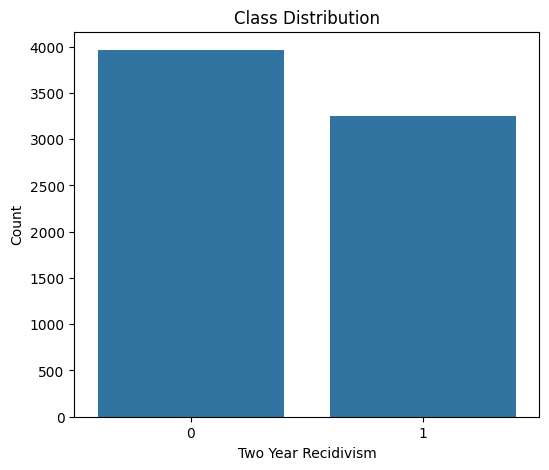

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Two Year Recidivism")
plt.ylabel("Count")

plt.show()

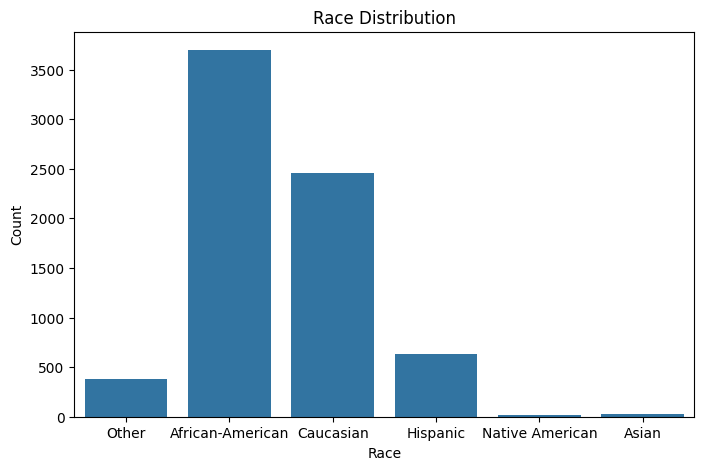

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['race'])

plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")

plt.show()

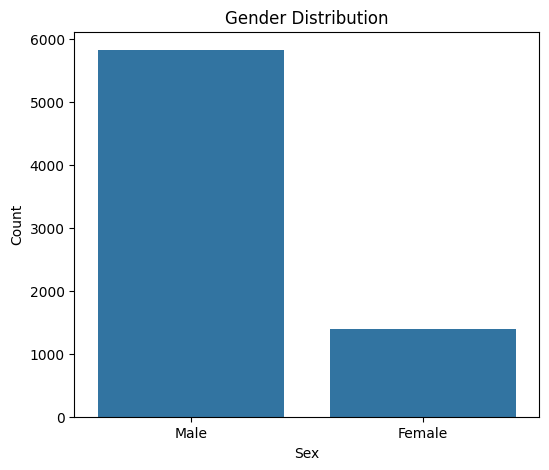

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x=df['sex'])

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

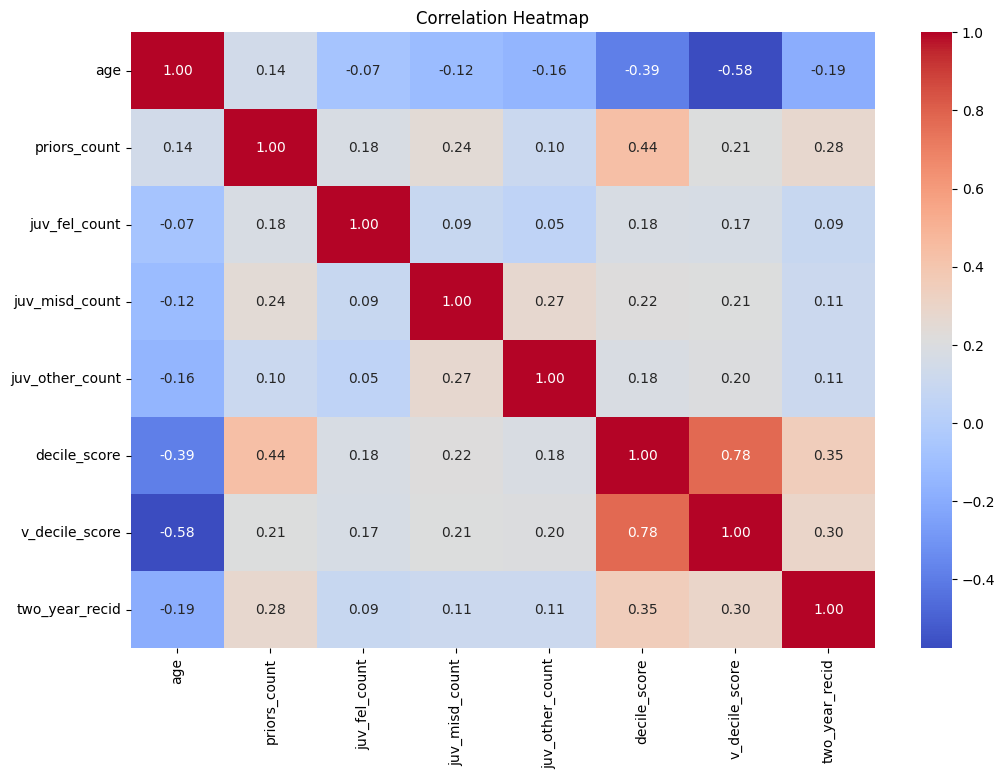

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

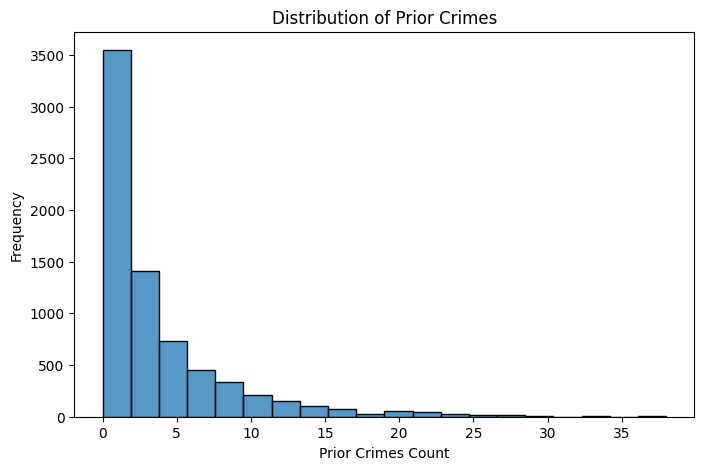

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['priors_count'], bins=20)

plt.title("Distribution of Prior Crimes")
plt.xlabel("Prior Crimes Count")
plt.ylabel("Frequency")

plt.show()

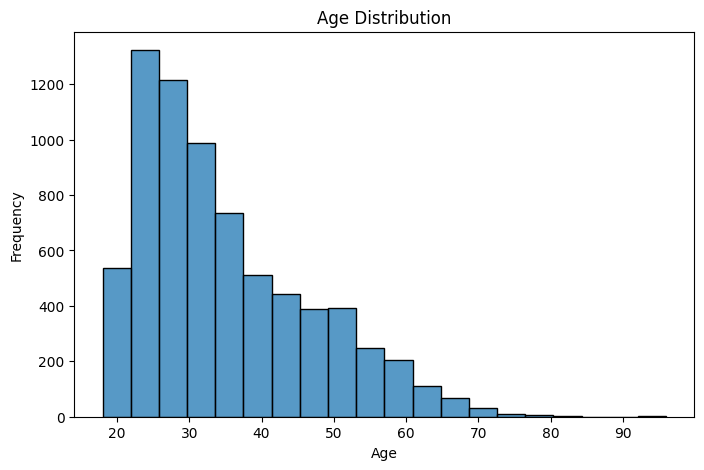

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

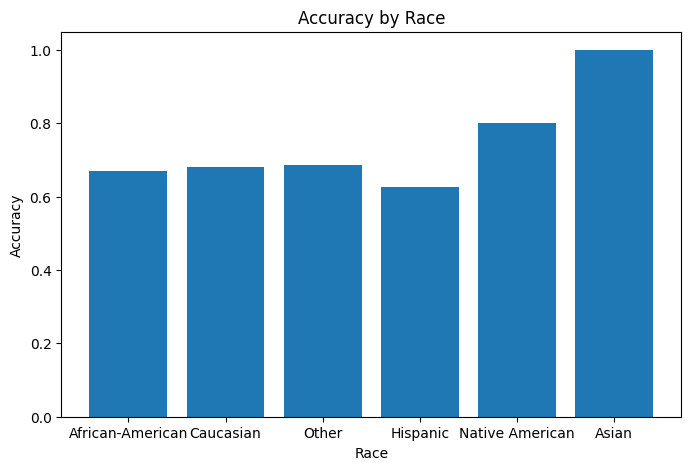

In [ ]:
race_accuracy = []

race_groups = X_test['race'].unique()

for race in race_groups:

    idx = X_test['race'] == race

    acc = accuracy_score(
        y_test[idx],
        predictions[idx]
    )

    race_accuracy.append(acc)

plt.figure(figsize=(8,5))

plt.bar(race_groups, race_accuracy)

plt.title("Accuracy by Race")
plt.xlabel("Race")
plt.ylabel("Accuracy")

plt.show()

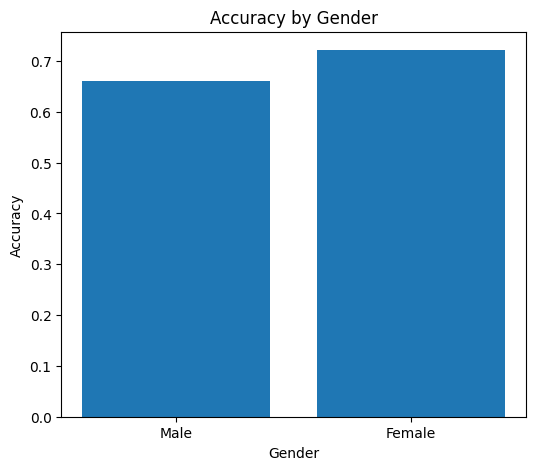

In [ ]:
gender_accuracy = []

gender_groups = X_test['sex'].unique()

for gender in gender_groups:

    idx = X_test['sex'] == gender

    acc = accuracy_score(
        y_test[idx],
        predictions[idx]
    )

    gender_accuracy.append(acc)

plt.figure(figsize=(6,5))

plt.bar(gender_groups, gender_accuracy)

plt.title("Accuracy by Gender")
plt.xlabel("Gender")
plt.ylabel("Accuracy")

plt.show()

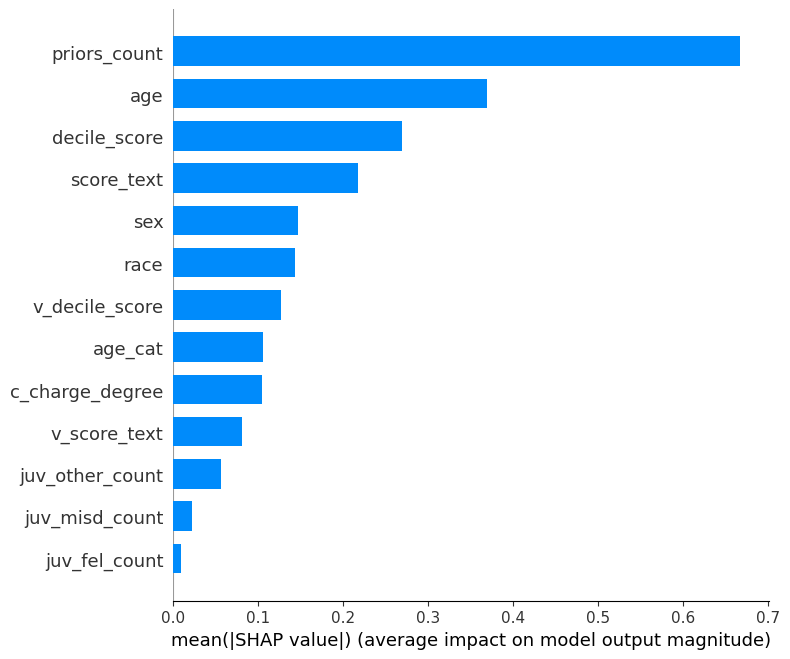

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

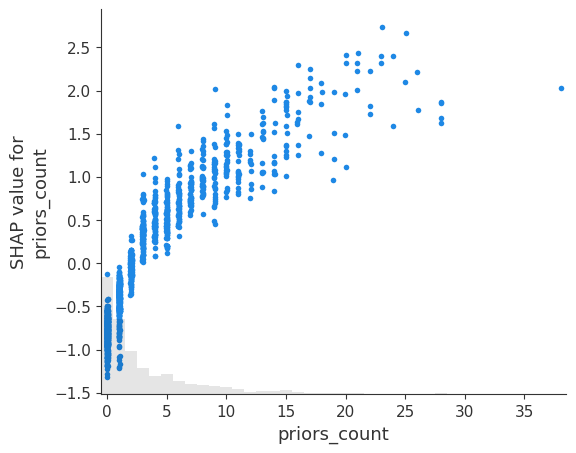

In [ ]:
shap.plots.scatter(
    shap_values[:, "priors_count"]
)

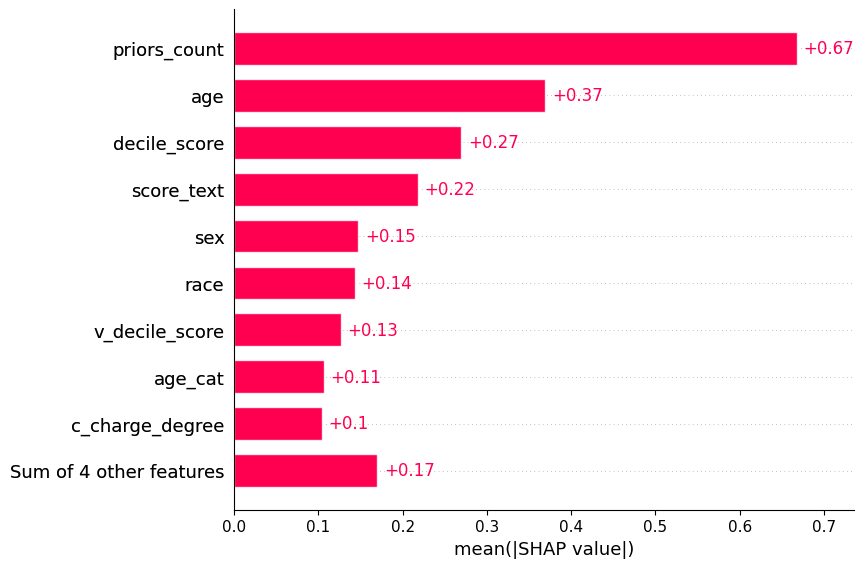

In [ ]:
shap.plots.bar(shap_values)

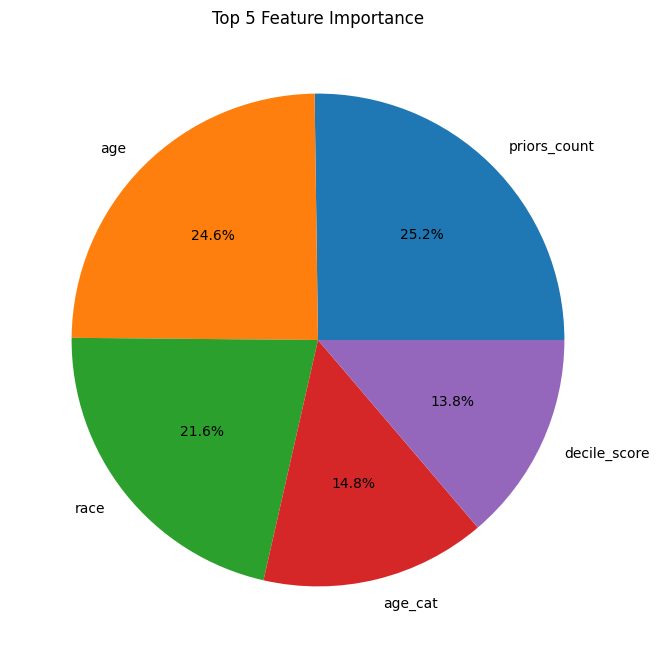

In [ ]:
top_features = feature_importance.head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_features['Importance'],
    labels=top_features['Feature'],
    autopct='%1.1f%%'
)

plt.title("Top 5 Feature Importance")

plt.show()

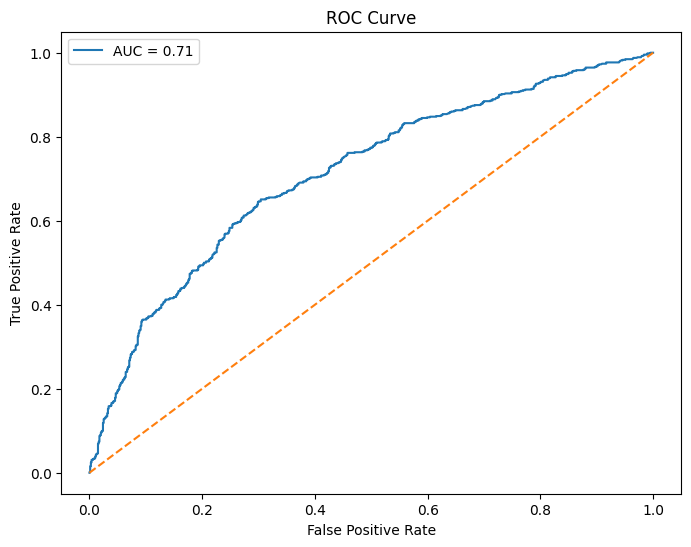

In [ ]:
from sklearn.metrics import roc_curve, auc

probs = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

## ROC Curve Analysis

The ROC curve evaluates the model’s discrimination capability between recidivism and non-recidivism cases.

A higher AUC value indicates better classification performance.

# Conclusion

This project analyzed fairness, bias, and explainability in the COMPAS recidivism prediction system using machine learning techniques.

A CatBoost classifier was trained to predict two-year recidivism outcomes, achieving moderate predictive performance while enabling detailed fairness and interpretability analysis.

SHAP and LIME explanations improved model transparency by identifying the most influential features affecting predictions.

The analysis also revealed potential fairness concerns across demographic groups, emphasizing the importance of ethical AI practices in sensitive criminal justice applications.

This study demonstrates that high predictive performance alone is insufficient in socially sensitive domains where fairness, accountability, and transparency are equally important.